# Equivalent Widths: Plots of comparison for MAST and JADES

Main parameters, colors, etc, for the plots

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib widget

# ==========================  Plot Setting  ========================== #

# Latex rendering
plt.rc('font', **{'family': 'serif', 'serif': ['palatino']}) #Helvetica
plt.rc('font', weight='bold')
plt.rc('text', usetex=True)

# ------- Cosmology palette (normalized RGB) ------- v1

COSMO_COLORS = {
    "color1": (120/255, 120/255, 120/255), #cool gray
    "color2": (150/255, 40/255, 40/255), #soft crimson
    "color3": (200/255, 140/255, 0/255), #warm gold
    "color4": (0/255, 110/255, 110/255), #dark teal
    "color5": (30/255, 60/255, 120/255), #deep blue
    }
"""
# ------- Cosmology palette (normalized RGB) ------- v2
COSMO_COLORS = {
    "color1": (241/255, 222/255, 222/255), #soft cream
    "color2": (212/255, 150/255, 167/255), #warm rose
    "color3": (93/255, 87/255, 107/255), #deep gray
    "color4": (255/255, 151/255, 107/255), #warm coral
    "color5": (108/255, 212/255, 254/255), #cool sky blue
    }
"""

sns.set_theme(
    style="ticks",
    context='paper',
    rc={
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "axes.grid": True,
    })

sns.set_palette([
    COSMO_COLORS["color1"],
    COSMO_COLORS["color2"],
    COSMO_COLORS["color3"],
    COSMO_COLORS["color4"],
    COSMO_COLORS["color5"],
    ])

#General Settings
plt.rc('axes', titlesize=18)     # fontsize of the axes title
plt.rc('axes', labelsize=18)     # fontsize of the x and y labels
plt.rc('axes', linewidth=1.65 )   # width of the frame
plt.rc('xtick', labelsize=16)    # fontsize of the tick labels
plt.rc('ytick', labelsize=16)    # fontsize of the tick labels
plt.rc('legend', fontsize=12)    # legend fontsize
plt.rc('font', size=18)          # controls default text sizes


Core code for arrays and data

In [20]:
from pathlib import Path
import pandas as pd
import numpy as np
    

#///////////////// Files and Data /////////////////////////////

# Leer archivo (ajusta el nombre del archivo)
source=Path("/home/nicolas/Documents/Research/PhD/JWST-Data/PRISM/")
plots_folder=source / "EW/EW-Plots"

data = pd.read_csv("/home/nicolas/Documents/Research/PhD/JWST-Data/PRISM/EW/EW-Data-Output/EW_output_new.tsv", sep='\t')

# Guardar columnas en arrays
ID_array = data.iloc[:,0].to_numpy()
z_array = data.iloc[:,1].to_numpy()

#Halpha data
mast_Ha = data.iloc[:,2].to_numpy()
mast_Ha_err = data.iloc[:,3].to_numpy()
jades_Ha = data.iloc[:,4].to_numpy()
jades_Ha_err = data.iloc[:,5].to_numpy()

#Hbeta data
mast_Hb = data.iloc[:,6].to_numpy()
mast_Hb_err = data.iloc[:,7].to_numpy()
jades_Hb = data.iloc[:,8].to_numpy()
jades_Hb_err = data.iloc[:,9].to_numpy()

#[oiii] data
mast_Oiii = data.iloc[:,10].to_numpy()
mast_Oiii_err = data.iloc[:,11].to_numpy()
jades_Oiii = data.iloc[:,12].to_numpy()
jades_Oiii_err = data.iloc[:,13].to_numpy()

 

# Definir variables para la gráfica
Ha_diff = jades_Ha - mast_Ha
DHa = np.sqrt(mast_Ha_err**2 + jades_Ha_err**2)

# Restore the dataframes from existing arrays
df_Ha = pd.DataFrame({
    'ID': ID_array,
    'redshift': z_array,
    'Ha_diff': Ha_diff,
    'DHa': DHa,
})
df_Ha['sigma'] = df_Ha['Ha_diff'].abs() / df_Ha['DHa']

# Hbeta data
Hb_diff = jades_Hb - mast_Hb
DHb = np.sqrt(mast_Hb_err**2 + jades_Hb_err**2)
df_Hb = pd.DataFrame({
    'ID': ID_array,
    'redshift': z_array,
    'Hb_diff': Hb_diff,
    'DHb': DHb,
})
df_Hb['sigma'] = df_Hb['Hb_diff'].abs() / df_Hb['DHb']

# [OIII] data
O3_diff = jades_Oiii - mast_Oiii
DO3 = np.sqrt(mast_Oiii_err**2 + jades_Oiii_err**2)
df_O3 = pd.DataFrame({
    'ID': ID_array,
    'redshift': z_array,
    'O3_diff': O3_diff,
    'DO3': DO3,
})
df_O3['sigma'] = df_O3['O3_diff'].abs() / df_O3['DO3']
# Drop NaN values from all dataframes
df_Ha = df_Ha.dropna()
df_Hb = df_Hb.dropna()
df_O3 = df_O3.dropna()

for df_name, diff_col, err_col in [
    ("df_Ha", "Ha_diff", "DHa"),
    ("df_Hb", "Hb_diff", "DHb"),
    ("df_O3", "O3_diff", "DO3"),
]:
    df = globals()[df_name]
    df[diff_col] = df[diff_col].abs()
    df["sigma"] = df[diff_col] / df[err_col]
    globals()[df_name] = df



## PLot of 1 - 1 Correspondence

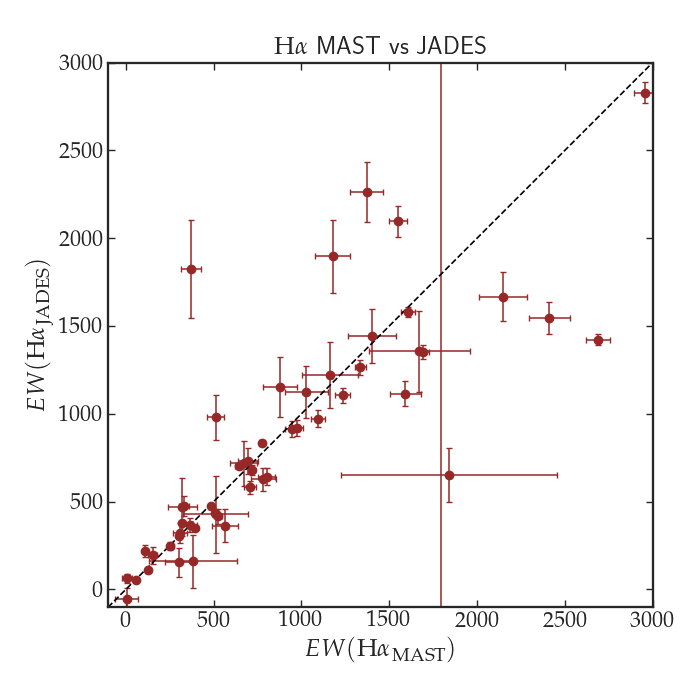

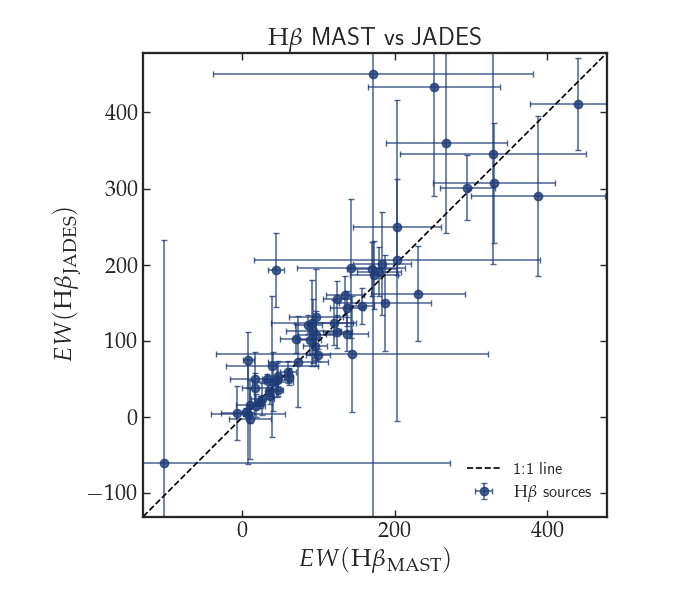

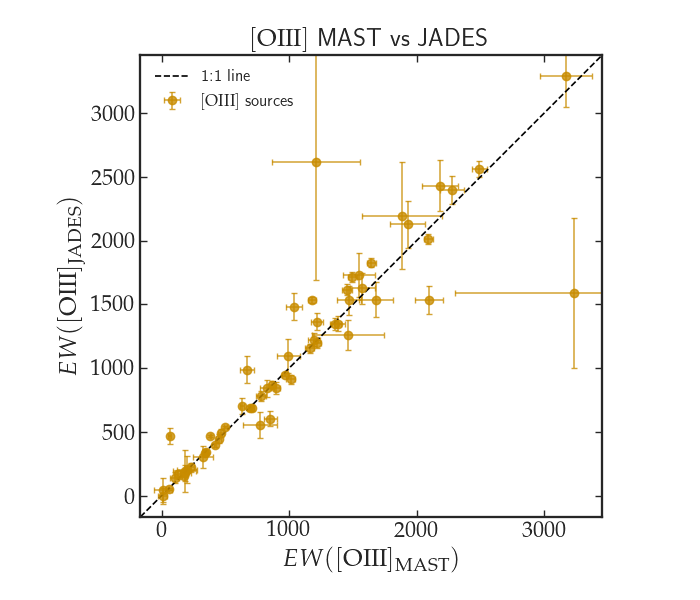

In [21]:

# ============ Halpha ================
# Show the values multiplied by -1
# 1-1 scatter plot for Halpha: MAST vs JADES
mask = np.isfinite(mast_Ha) & np.isfinite(jades_Ha)
x = -mast_Ha[mask]
y = -jades_Ha[mask]
xerr = mast_Ha_err[mask]
yerr = jades_Ha_err[mask]

fig, ax = plt.subplots(figsize=(7, 7))

ax.errorbar(
    x, y,
    xerr=xerr,
    yerr=yerr,
    fmt='o',
    ms=6,
    color=COSMO_COLORS["color2"],
    ecolor=COSMO_COLORS["color2"],
    elinewidth=1.1,
    capsize=2,
    alpha=1,
    label=r'$\mathrm{H}\alpha$ sources'
)

vmin = np.nanmin(np.concatenate([x, y]))
vmax = np.nanmax(np.concatenate([x, y]))
pad = 0.05 * (vmax - vmin) if (vmax > vmin) else 1.0
lims = [vmin - pad, vmax + pad]
ax.plot(lims, lims, color="black", linestyle="--", linewidth=1.2, label="1:1 line")

ax.set_xlabel(r'$ EW(\mathrm{H}\alpha_{\rm MAST})$')
ax.set_ylabel(r'$ EW(\mathrm{H}\alpha_{\rm JADES})$')
ax.set_title(r'$\mathrm{H}\alpha$ MAST vs JADES')
ax.set_aspect("equal", adjustable="box")
ax.set_xlim([-100, 3000])
ax.set_ylim([-100, 3000])

ax.grid(False)

plt.tight_layout()
plt.show()

# ============ H beta ================
# 1-1 scatter plot for Hbeta: MAST vs JADES
mask = np.isfinite(mast_Hb) & np.isfinite(jades_Hb)
x = -mast_Hb[mask]
y = -jades_Hb[mask]
xerr = mast_Hb_err[mask]
yerr = jades_Hb_err[mask]

fig, ax = plt.subplots(figsize=(7, 6))
ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='o', ms=6,
            color=COSMO_COLORS["color5"], ecolor=COSMO_COLORS["color5"],
            elinewidth=1.1, capsize=2, alpha=0.8, label=r'$\mathrm{H}\beta$ sources')

# 1:1 line and limits based on data
vmin = np.nanmin(np.concatenate([x, y]))
vmax = np.nanmax(np.concatenate([x, y]))
pad = 0.05 * (vmax - vmin) if (vmax > vmin) else 1.0
lims = [vmin - pad, vmax + pad]
ax.plot(lims, lims, color="black", linestyle="--", linewidth=1.2, label="1:1 line")

ax.set_xlabel(r'$ EW(\mathrm{H}\beta_{\rm MAST})$')
ax.set_ylabel(r'$ EW(\mathrm{H}\beta_{\rm JADES})$')
ax.set_title(r'$\mathrm{H}\beta$ MAST vs JADES')
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.grid(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


# 1-1 scatter plot for [OIII]: MAST vs JADES
mask = np.isfinite(mast_Oiii) & np.isfinite(jades_Oiii)
x = -mast_Oiii[mask]
y = -jades_Oiii[mask]
xerr = mast_Oiii_err[mask]
yerr = jades_Oiii_err[mask]

fig, ax = plt.subplots(figsize=(7, 6))
ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='o', ms=6,
            color=COSMO_COLORS["color3"], ecolor=COSMO_COLORS["color3"],
            elinewidth=1.1, capsize=2, alpha=0.8, label=r'$[\mathrm{OIII}]$ sources')

vmin = np.nanmin(np.concatenate([x, y]))
vmax = np.nanmax(np.concatenate([x, y]))
pad = 0.05 * (vmax - vmin) if (vmax > vmin) else 1.0
lims = [vmin - pad, vmax + pad]
ax.plot(lims, lims, color="black", linestyle="--", linewidth=1.2, label="1:1 line")

ax.set_xlabel(r'$ EW([\mathrm{OIII}]_{\rm MAST})$')
ax.set_ylabel(r'$ EW([\mathrm{OIII}]_{\rm JADES})$')
ax.set_title(r'$[\mathrm{OIII}]$ MAST vs JADES')
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.grid(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In these plots, we observe a general agreement between the set of estimations obtained by each source. This can be seen most notably in the third figure, specially in the lower values of EW([OIII]) ($\lesssim 1200$), where we see low dispersion and data point with low errors as well. For the second figure, while scatter is bigger and the data points look more disperse, the range of values is smaller (400 wrt 3000 in the third plot), and the errors for the EW($H\beta$) are also bigger, which still alows us to conclude a general agreement between the values. The third figure perhaps shows the most notable differences, in regards to the fact that the errors are smaller yet the dispersion is quite notable. Furthermore, for this line we observe the largest number of outliers, and the most notable of them, which turns out to be object 10009693. For this object the estimation on JADES spectrum is 25000, with respect to -1800 in the MAST reduced spectrum. For this object, the estimation of the EW of the other lines is equally bad, differing by 50% on what we obtain with MAST estimation. 

## Plot of the Difference as function of redshift

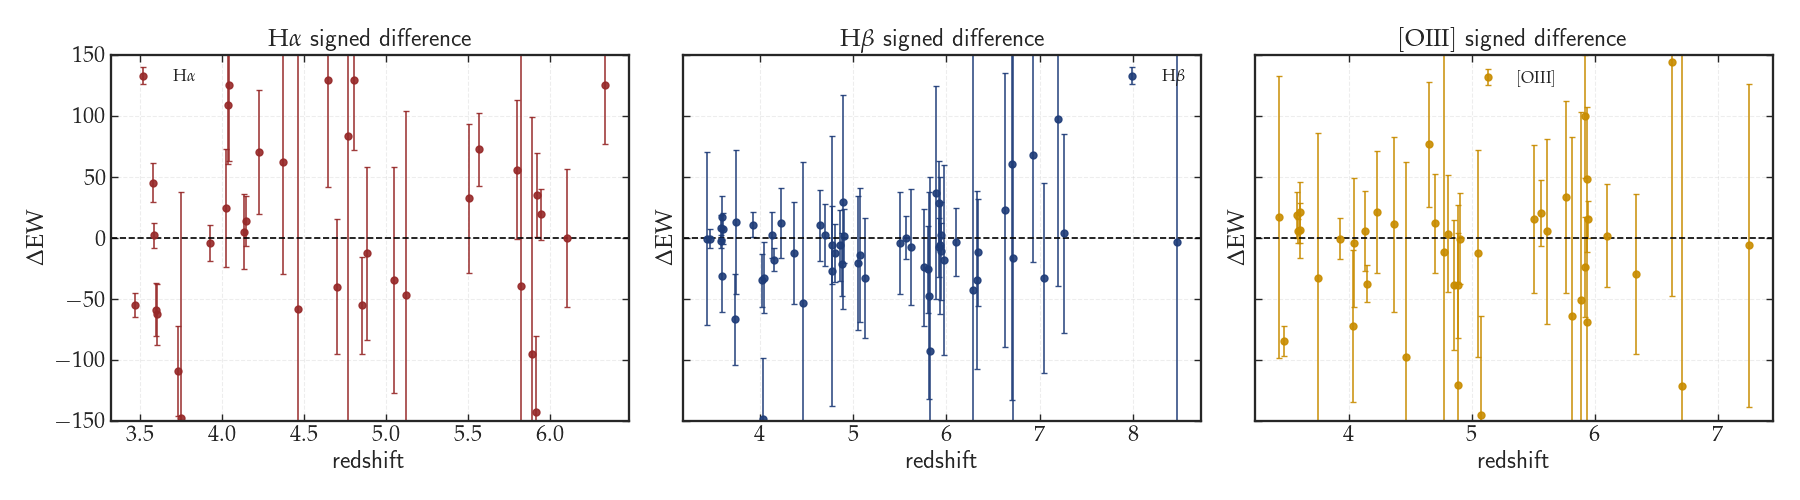

In [22]:
# Signed EW difference vs redshift for Halpha, Hbeta, and [OIII]
# Use propagated errors = sqrt(mast_err^2 + jades_err^2)
# Keep only signed differences, not absolute values
# Plot each line separately and keep y-limits in [-150, 150]

def signed_diff_plot(x, y, yerr, ax, color, label):
    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(yerr)
    x_sel = x[mask]
    y_sel = y[mask]
    yerr_sel = yerr[mask]
    good = np.isfinite(y_sel) & np.isfinite(yerr_sel) & (-150 <= y_sel) & (y_sel <= 150)
    ax.errorbar(
        x_sel[good], y_sel[good], yerr=yerr_sel[good],
        fmt='o', ms=5, color=color, ecolor=color,
        elinewidth=1.2, capsize=2, alpha=0.9, label=label
    )
    ax.axhline(0, color='black', linestyle='--', linewidth=1.2)
    ax.set_xlabel('redshift')
    ax.set_ylabel(r'$\Delta \mathrm{EW}$')
    ax.set_ylim(-150, 150)
    ax.grid(True, which='both', ls='--', alpha=0.35)
    ax.legend(frameon=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Halpha
mask_Ha = np.isfinite(mast_Ha) & np.isfinite(jades_Ha) & np.isfinite(mast_Ha_err) & np.isfinite(jades_Ha_err)
x_Ha = z_array[mask_Ha]
y_Ha = (jades_Ha - mast_Ha)[mask_Ha]
yerr_Ha = np.sqrt(mast_Ha_err[mask_Ha]**2 + jades_Ha_err[mask_Ha]**2)
signed_diff_plot(x_Ha, y_Ha, yerr_Ha, axes[0], COSMO_COLORS["color2"], r'$\mathrm{H}\alpha$')
axes[0].set_title(r'$\mathrm{H}\alpha$ signed difference')

# Hbeta
mask_Hb = np.isfinite(mast_Hb) & np.isfinite(jades_Hb) & np.isfinite(mast_Hb_err) & np.isfinite(jades_Hb_err)
x_Hb = z_array[mask_Hb]
y_Hb = (jades_Hb - mast_Hb)[mask_Hb]
yerr_Hb = np.sqrt(mast_Hb_err[mask_Hb]**2 + jades_Hb_err[mask_Hb]**2)
signed_diff_plot(x_Hb, y_Hb, yerr_Hb, axes[1], COSMO_COLORS["color5"], r'$\mathrm{H}\beta$')
axes[1].set_title(r'$\mathrm{H}\beta$ signed difference')

# [OIII]
mask_O3 = np.isfinite(mast_Oiii) & np.isfinite(jades_Oiii) & np.isfinite(mast_Oiii_err) & np.isfinite(jades_Oiii_err)
x_O3 = z_array[mask_O3]
y_O3 = (jades_Oiii - mast_Oiii)[mask_O3]
yerr_O3 = np.sqrt(mast_Oiii_err[mask_O3]**2 + jades_Oiii_err[mask_O3]**2)
signed_diff_plot(x_O3, y_O3, yerr_O3, axes[2], COSMO_COLORS["color3"], r'$[\mathrm{OIII}]$')
axes[2].set_title(r'$[\mathrm{OIII}]$ signed difference')

plt.tight_layout()
plt.show()


These plots are very similar in the information they contain to the previous one. Here, we can observe the difference in the estimation of the equavalen width, and the errors cuadratically summed. The additional information is the redshift, but this is not a relevant information here since there is no clear tendency on any redshift dependence with the difference. However, that by itself can be considered a useful results, since one of the pipelines that we are comparing is supposed to be designed for high redshift objects, but there is no particular redshift dependence in the redshift estimation with each pipeline, this makes us lose confidence in JADES methodology.

## Significance vs Redshift

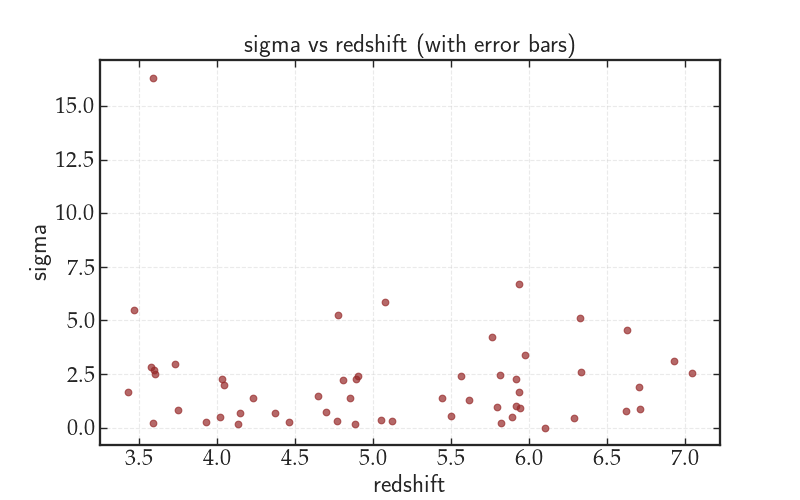

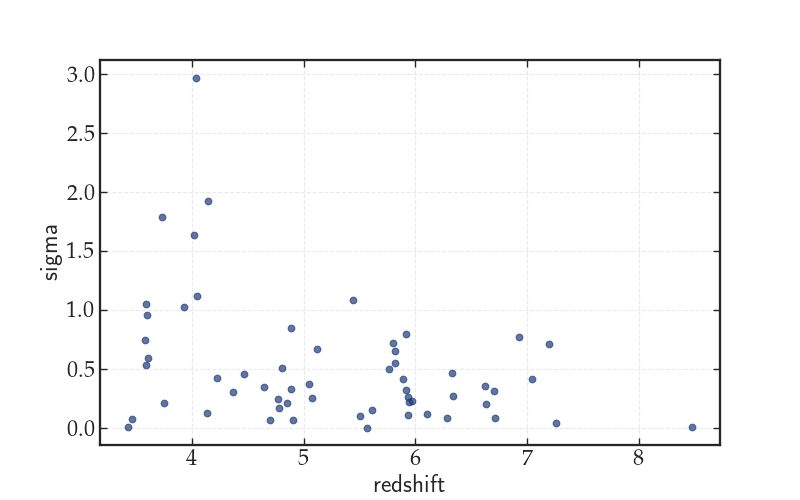

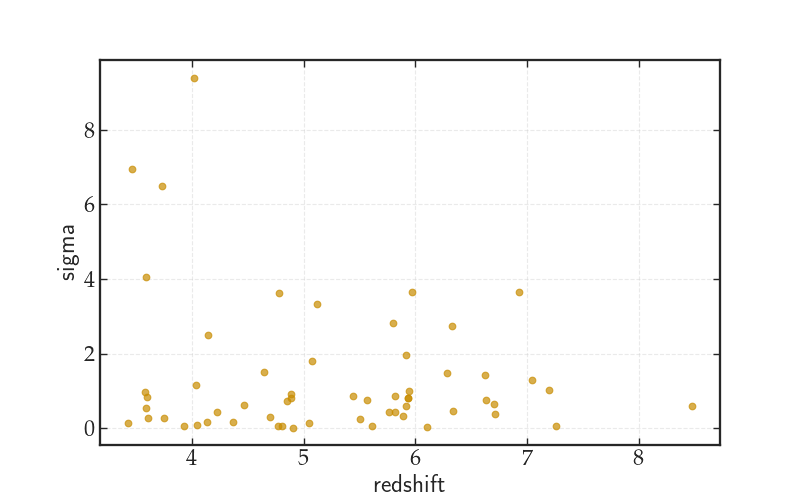

In [23]:
# Scatter plot of Ha_diff vs redshift with error bars
df_plot = df_Ha.dropna(subset=['redshift', 'Ha_diff', 'DHa', 'sigma'])
x = df_plot['redshift']
y = df_plot['sigma']
yerr = df_plot['DHa']

plt.figure(figsize=(8,5))
plt.scatter(x, y, color=COSMO_COLORS["color2"], label='H-alpha', alpha=0.7)
plt.xlabel('redshift')
plt.ylabel('sigma')
plt.title('sigma vs redshift (with error bars)')
plt.grid(True, which='both', ls='--', alpha=0.4)


plt.show()

# Scatter plot of Ha_diff vs redshift with error bars
df_plot = df_Hb.dropna(subset=['redshift', 'Hb_diff', 'DHb', 'sigma'])
x = df_plot['redshift']
y = df_plot['sigma']
yerr = df_plot['DHb']

plt.figure(figsize=(8,5))
plt.scatter(x, y, color=COSMO_COLORS["color5"], label='H-beta', alpha=0.7)
plt.xlabel('redshift')
plt.ylabel('sigma')
plt.grid(True, which='both', ls='--', alpha=0.4)

plt.show()

# Scatter plot of Ha_diff vs redshift with error bars
df_plot = df_O3.dropna(subset=['redshift', 'O3_diff', 'DO3', 'sigma'])
x = df_plot['redshift']
y = df_plot['sigma']
yerr = df_plot['DO3']

plt.figure(figsize=(8,5))
plt.scatter(x, y, color=COSMO_COLORS["color3"], label='[OIII]', alpha=0.7)
plt.xlabel('redshift')
plt.ylabel('sigma')
plt.grid(True, which='both', ls='--', alpha=0.4)

plt.show()

Here, we can observe a more statistical version of the previous plot, since we can observe here the significance: ratio between the difference and the errors. The significance removes the weight of the difference when the errors are large. We observe, however, still, very large values of significance, which is even more undesirable than having large differences with large errors. The line with more objects with significance larger than 5 is Ha, with 6, standing out an object with 16. For OIII, significance above 4 is present for four objects, all at low redshift; meanwhile, for Hb, significance is never higher than 3, this is however due to the very large  errors that we saw in the previous plots. 

## Histogram for the significance in each of the categories

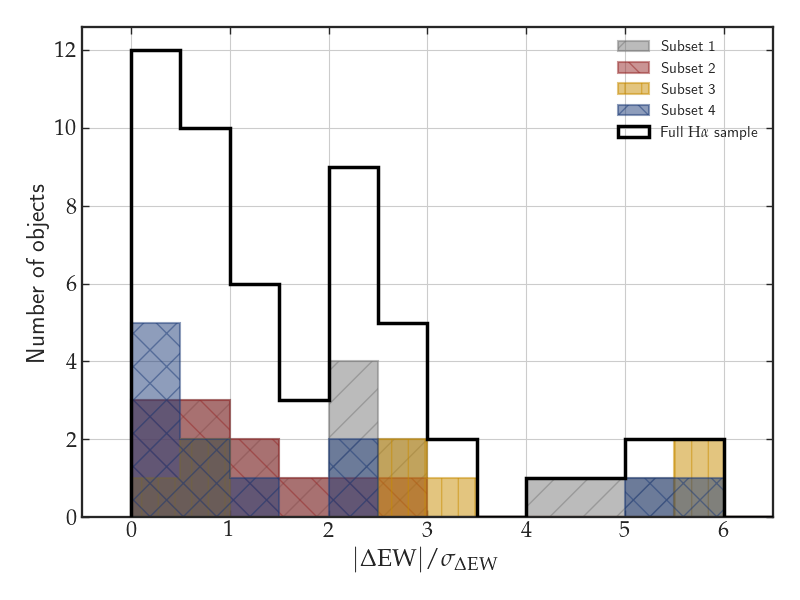

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))

# Common bins for every histogram
bins = np.arange(0, 7, .5)

# Colors and hatch patterns for the four subsets
colors = [
    COSMO_COLORS["color1"],
    COSMO_COLORS["color2"],
    COSMO_COLORS["color3"],
    COSMO_COLORS["color5"],
]

hatches = [
    '/',      # diagonal
    '\\',     # opposite diagonal
    '|',      # vertical
    'x',      # crossed
]
# /////////////////// Halpha sigma subsets /////////////////////////////

# Define the four ID subsets
Ha_groups = {
    1: [
        4297, 4404, 6002, 7762, 7938, 8013, 8083, 8113, 9422,
        16625, 16745, 18090, 18846, 19606, 10000626, 10009506,
        10013704, 10013905, 10016186, 10016374, 10035295, 10056849
    ],

    2: [
        3334, 4197, 6384, 7624, 8013, 8079, 9452, 9753, 20961,
        10005113, 10005217, 10005447, 10009693, 10009848,
        100013545, 100013620
    ],

    3: [
        3184, 4270, 7809, 17566, 18028, 19342,
        10013618, 10015338
    ],

    4: [
        5329, 5759, 6246, 7507, 7892, 17072, 17260, 17777,
        18976, 19519, 22251, 10001892, 100013609, 10015338
    ]
}

# Create the four filtered DataFrames
df_Ha_1 = df_Ha[df_Ha['ID'].isin(Ha_groups[1])].copy()
df_Ha_2 = df_Ha[df_Ha['ID'].isin(Ha_groups[2])].copy()
df_Ha_3 = df_Ha[df_Ha['ID'].isin(Ha_groups[3])].copy()
df_Ha_4 = df_Ha[df_Ha['ID'].isin(Ha_groups[4])].copy()


# Plot the four subsets
for (group_number, IDs), color, hatch in zip(
    Ha_groups.items(), colors, hatches
):

    subset = df_Ha[df_Ha['ID'].isin(IDs)]

    ax.hist(
        subset['sigma'],
        bins=bins,
        histtype='stepfilled',
        alpha=0.50,               # light transparent filling
        color=color,
        edgecolor=color,
        linewidth=1.5,
        hatch=hatch,
        label=f'Subset {group_number}',
    )


# -------------------------------------------------------
# Full Halpha sample — black outline, plotted on top
# -------------------------------------------------------

ax.hist(
    df_Ha['sigma'],
    bins=bins,
    histtype='step',
    color='black',
    linewidth=2.5,
    label=r'Full $\mathrm{H}\alpha$ sample',
    zorder=10,
)



# Labels
ax.set_xlabel(r'$|\Delta \mathrm{EW}|/\sigma_{\Delta\mathrm{EW}}$')
ax.set_ylabel(r'Number of objects')

ax.set_xlim(-.50, 6.5)

ax.legend(
    frameon=False,
    fontsize=11
)

plt.tight_layout()
plt.show()

This is the most complete plot for this analysis. We show a histogram of the significance, given by $ | \Delta EW | / \sigma_{\Delta EW}$, for our full sample (black thick line). Seen more compactly, we observe that most of the objects fall within 1 to 2 sigmas. There is a larger number than desired with $2\sigma$ deviation, by only 2 at 4, 4.5, 5, 5.5, which lead us to conclude than, insofar of EW estimation, the agreement for the full sample can be considered statistically equivalent, but there are considerable outliers. In the case of the object with significance 16, which is 10035295. we can observe that this object is in the first category of the difference of the spectra. In this plot, we also observe the four different categories of the difference in the reduced spectrum of the objects, and where the objects that belong to each category fall in the significance histogram. Subset 4 is the group of objects for which we observe general agreement, however, even for these obects there are a couple of estimations that disagree by more than $5\sigma$, the rest, however, as expected, lie below $2.5\sigma$. In the case of Subset 3 objects, which are those with a different level of the continuum, the significance distribution is broad and non very indicative. At least in what respects to the estimation of EW, the four categories do not seem to correlate with any kind of discrepancy found, expect for a couple of cases. 

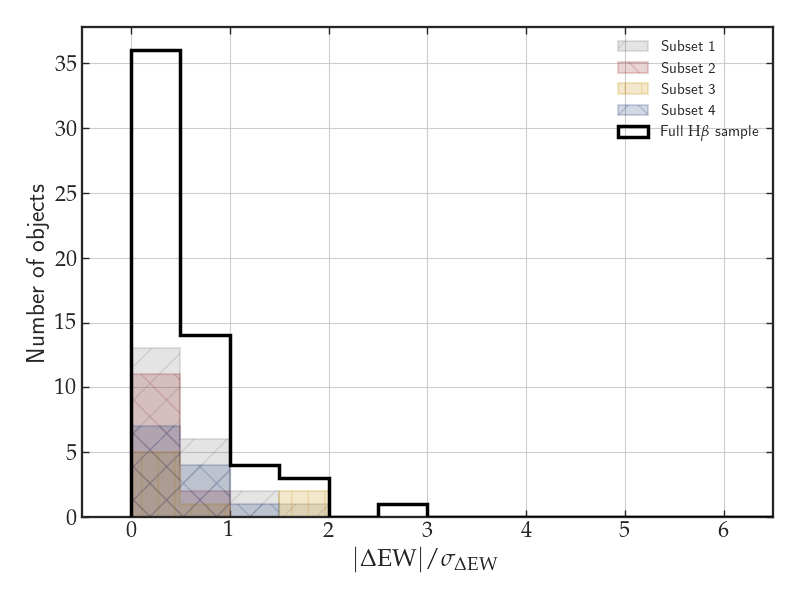

In [25]:
# /////////////////// Hbeta sigma subsets /////////////////////////////

fig, ax = plt.subplots(figsize=(8, 6))

# Plot subsets
for (group_number, IDs), color, hatch in zip(
    Ha_groups.items(), colors, hatches
):

    subset = df_Hb[df_Hb['ID'].isin(IDs)]

    ax.hist(
        subset['sigma'],
        bins=bins,
        histtype='stepfilled',
        alpha=0.20,
        color=color,
        edgecolor=color,
        linewidth=1.5,
        hatch=hatch,
        label=f'Subset {group_number}',
    )

# Full Hbeta sample on top
ax.hist(
    df_Hb['sigma'],
    bins=bins,
    histtype='step',
    color='black',
    linewidth=2.5,
    label=r'Full $\mathrm{H}\beta$ sample',
    zorder=10,
)

ax.set_xlabel(r'$|\Delta \mathrm{EW}|/\sigma_{\Delta\mathrm{EW}}$')
ax.set_ylabel(r'Number of objects')
ax.set_xlim(-.50, 6.5)

ax.legend(frameon=False, fontsize=11)

plt.tight_layout()
plt.show()

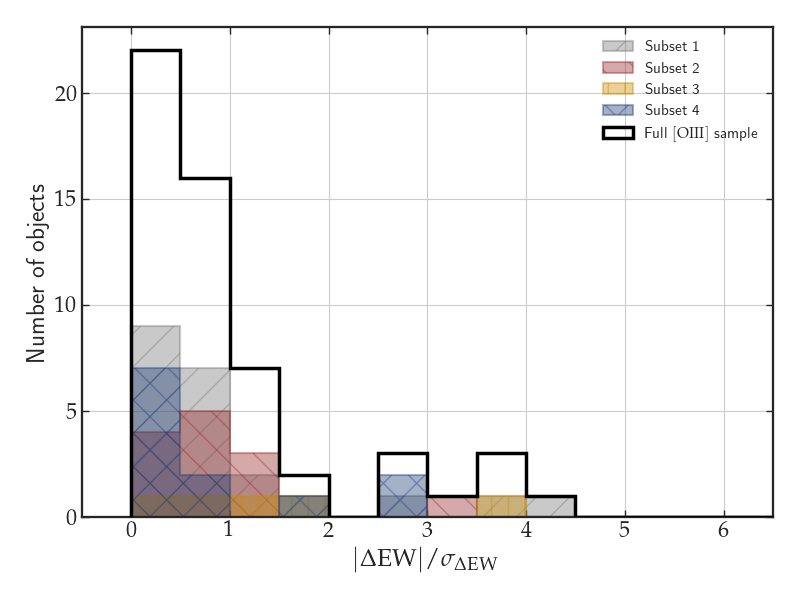

In [26]:
# /////////////////// [OIII] sigma subsets /////////////////////////////

fig, ax = plt.subplots(figsize=(8, 6))
# Plot subsets
for (group_number, IDs), color, hatch in zip(
    Ha_groups.items(), colors, hatches
):

    subset = df_O3[df_O3['ID'].isin(IDs)]

    ax.hist(
        subset['sigma'],
        bins=bins,
        histtype='stepfilled',
        alpha=0.40,
        color=color,
        edgecolor=color,
        linewidth=1.5,
        hatch=hatch,
        label=f'Subset {group_number}',
    )

# Full [OIII] sample on top
ax.hist(
    df_O3['sigma'],
    bins=bins,
    histtype='step',
    color='black',
    linewidth=2.5,
    label=r'Full $[\mathrm{OIII}]$ sample',
    zorder=10,
)


ax.set_xlabel(r'$|\Delta \mathrm{EW}|/\sigma_{\Delta\mathrm{EW}}$')
ax.set_ylabel(r'Number of objects')
ax.set_xlim(-.50, 6.5)

ax.legend(frameon=False, fontsize=11)

plt.tight_layout()
plt.show()